# Knowledge Distillation Experiment — 500 Videos

**Pipeline:**
1. Extract features (ImageBind + MUSIQ/TOPIQ + BLIP + MiniLM) → 500 videos
2. Train **Teacher** (6M params, ALL features) → upper bound
3. Train **Student baseline** (900K params, no KD)
4. Train **Student + KD** (900K params, with distillation)
5. Compare → prove KD helps

**Kaggle:** Add dataset `nguyntuncng/snapugc-dataset` as input, use GPU T4

In [1]:
## 1. Install & Setup
!pip install -q pyiqa sentence-transformers eva-decord pytorchvideo timm
!git clone https://github.com/facebookresearch/ImageBind.git /kaggle/working/ImageBind 2>/dev/null || true
!pip install -e /kaggle/working/ImageBind -q

import os, sys, json, time, gc, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.stats import spearmanr, pearsonr, kendalltau
from tqdm.auto import tqdm
from PIL import Image
from datetime import datetime
import torchvision.transforms.functional as F_tv
sys.modules['torchvision.transforms.functional_tensor'] = F_tv

warnings.filterwarnings('ignore')
sys.path.insert(0, '/kaggle/working/ImageBind')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CPU_DEVICE = "cpu"

INPUT_DIR = "/kaggle/input/datasets/nguyntuncng/snapugc-dataset"
if not os.path.exists(INPUT_DIR):
    INPUT_DIR = "/kaggle/input/snapugc-dataset"
OUTPUT_DIR = "/kaggle/working"

TRAIN_CSV = os.path.join(INPUT_DIR, "train_data.csv")
TRAIN_VIDEO_DIR = os.path.join(INPUT_DIR, "train_videos/train_videos")

MAX_VIDEOS = 500
NUM_SCORE_FRAMES = 4
NUM_VISUAL_FRAMES = 4

print(f"Device: {DEVICE}")
print(f"Input: {INPUT_DIR}")
print(f"Videos: {MAX_VIDEOS}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 13.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00


## 2. Feature Extraction (Teacher Ensemble)

In [2]:
class QualityScorer:
    def __init__(self):
        import pyiqa
        self.device = torch.device(DEVICE)
        self.musiq = pyiqa.create_metric('musiq', device=self.device)
        self.topiq = pyiqa.create_metric('topiq_nr', device=self.device)
        print(f"[QualityScorer] on {self.device}")

    def score(self, video_path, num_frames=4):
        try:
            from decord import VideoReader, cpu
            vr = VideoReader(video_path, ctx=cpu(0))
            total = len(vr)
            if total == 0: return {"aesthetic": 5.0, "technical": 5.0}
            indices = np.linspace(0, total - 1, num_frames, dtype=int)
            frames = vr.get_batch(indices).asnumpy()
            aes, tech = [], []
            for f in frames:
                t = torch.from_numpy(f).permute(2, 0, 1).float().unsqueeze(0) / 255.0
                t = t.to(self.device)
                with torch.no_grad():
                    aes.append(self.musiq(t).item())
                    tech.append(self.topiq(t).item())
            return {"aesthetic": round(max(0, min(10, np.mean(aes)/10)), 2),
                    "technical": round(max(0, min(10, np.mean(tech)*10)), 2)}
        except Exception as e:
            return {"aesthetic": 5.0, "technical": 5.0}

    def unload(self):
        del self.musiq, self.topiq; gc.collect(); torch.cuda.empty_cache()


class VisualEncoder:
    def __init__(self):
        from imagebind.models import imagebind_model
        from imagebind.models.imagebind_model import ModalityType
        self.ModalityType = ModalityType
        self.model = imagebind_model.imagebind_huge(pretrained=True).to(DEVICE).eval()
        print(f"[VisualEncoder] ImageBind on {DEVICE}")

    def embed(self, video_path, num_frames=4):
        try:
            from decord import VideoReader, cpu
            from torchvision import transforms
            vr = VideoReader(video_path, ctx=cpu(0))
            total = len(vr)
            if total == 0: return None
            indices = np.linspace(0, total - 1, num_frames, dtype=int)
            frames = vr.get_batch(indices).asnumpy()
            preprocess = transforms.Compose([
                transforms.Resize(224), transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize([0.48145466, 0.4578275, 0.40821073],
                                     [0.26862954, 0.26130258, 0.27577711]),
            ])
            tensors = [preprocess(Image.fromarray(f)) for f in frames]
            video_tensor = torch.stack(tensors).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                embs = self.model({self.ModalityType.VISION: video_tensor})
            emb = embs[self.ModalityType.VISION].cpu().numpy().flatten()
            emb = emb / (np.linalg.norm(emb) + 1e-8)
            return emb.tolist()
        except Exception as e:
            print(f"  [Visual] Error: {e}")
            return None

    def unload(self):
        del self.model; gc.collect(); torch.cuda.empty_cache()


class CaptionGenerator:
    def __init__(self):
        from transformers import BlipProcessor, BlipForConditionalGeneration
        self.processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
        self.model = BlipForConditionalGeneration.from_pretrained(
            "Salesforce/blip-image-captioning-base").to(DEVICE).eval()
        print(f"[CaptionGenerator] BLIP on {DEVICE}")

    def caption(self, video_path):
        try:
            from decord import VideoReader, cpu
            vr = VideoReader(video_path, ctx=cpu(0))
            total = len(vr)
            if total == 0: return ""
            frame = vr[total // 2].asnumpy()
            inputs = self.processor(images=Image.fromarray(frame), return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                ids = self.model.generate(**inputs, max_new_tokens=40)
            return self.processor.decode(ids[0], skip_special_tokens=True).strip()
        except:
            return ""

    def unload(self):
        del self.model, self.processor; gc.collect(); torch.cuda.empty_cache()


class TextEncoder:
    def __init__(self):
        from sentence_transformers import SentenceTransformer
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        self.dim = self.model.get_sentence_embedding_dimension()
        print(f"[TextEncoder] MiniLM dim={self.dim}")

    def encode(self, title="", description="", caption=""):
        parts = []
        if title and str(title).strip(): parts.append(f"Title: {str(title).strip()}")
        if description and str(description).strip(): parts.append(f"Description: {str(description).strip()}")
        if caption and str(caption).strip(): parts.append(f"Visual: {str(caption).strip()}")
        if not parts: return [0.0] * self.dim
        emb = self.model.encode(" | ".join(parts), normalize_embeddings=True)
        return emb.tolist()

    def unload(self):
        del self.model; gc.collect()

print("Feature extractors defined")

Feature extractors defined


In [3]:
## Run feature extraction for 500 videos
FEATURES_PATH = os.path.join(OUTPUT_DIR, "features_500.json")

df = pd.read_csv(TRAIN_CSV)
print(f"CSV: {len(df)} entries")

work = []
for _, row in df.iterrows():
    vid_id = str(row['Id'])
    vid_path = os.path.join(TRAIN_VIDEO_DIR, f"{vid_id}.mp4")
    if os.path.exists(vid_path) and pd.notna(row.get('ECR')):
        work.append({
            'id': vid_id, 'path': vid_path,
            'ecr': float(row['ECR']),
            'title': str(row.get('Title', '')) if pd.notna(row.get('Title', '')) else '',
            'description': str(row.get('Description', '')) if pd.notna(row.get('Description', '')) else '',
        })
work = work[:MAX_VIDEOS]
print(f"Processing {len(work)} videos")

scorer = QualityScorer()
captioner = CaptionGenerator()
visual_enc = VisualEncoder()
text_enc = TextEncoder()

results = []
t0 = time.time()
for item in tqdm(work, desc="Extracting features"):
    try:
        quality = scorer.score(item['path'], NUM_SCORE_FRAMES)
        caption = captioner.caption(item['path'])
        visual_emb = visual_enc.embed(item['path'], NUM_VISUAL_FRAMES)
        text_emb = text_enc.encode(item['title'], item['description'], caption)
        results.append({
            'video_id': item['id'], 'ecr': item['ecr'],
            'title': item['title'], 'description': item['description'],
            'caption': caption,
            'visual_emb': visual_emb, 'text_emb': text_emb,
            'quality_scores': quality,
        })
    except Exception as e:
        print(f"  Error {item['id']}: {e}")

scorer.unload(); captioner.unload(); visual_enc.unload(); text_enc.unload()
torch.cuda.empty_cache(); gc.collect()

valid = [r for r in results if r['visual_emb'] is not None]
with open(FEATURES_PATH, 'w') as f:
    json.dump(valid, f)

elapsed = time.time() - t0
ecrs = [r['ecr'] for r in valid]
print(f"\nExtracted {len(valid)} samples in {elapsed/60:.1f} min ({elapsed/len(valid):.1f}s/video)")
print(f"ECR: mean={np.mean(ecrs):.4f}, std={np.std(ecrs):.4f}")
print(f"Saved: {FEATURES_PATH}")

CSV: 106192 entries
Processing 500 videos
Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/musiq_koniq_ckpt-e95806b9.pth" to /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth



100%|██████████| 104M/104M [00:00<00:00, 299MB/s] 


Loading pretrained model MUSIQ from /root/.cache/torch/hub/pyiqa/musiq_koniq_ckpt-e95806b9.pth


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Downloading: "https://huggingface.co/chaofengc/IQA-PyTorch-Weights/resolve/main/cfanet_nr_koniq_res50-9a73138b.pth" to /root/.cache/torch/hub/pyiqa/cfanet_nr_koniq_res50-9a73138b.pth



...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[TextEncoder] MiniLM dim=384


Extracting features:   0%|          | 0/500 [00:00<?, ?it/s]


Extracted 500 samples in 13.7 min (1.6s/video)
ECR: mean=0.0494, std=0.0311
Saved: /kaggle/working/features_500.json


## 3. Model Definitions (Teacher + Student)

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * 2, dim), nn.Dropout(dropout))
        self.norm = nn.LayerNorm(dim)
    def forward(self, x):
        return self.norm(x + self.net(x))


class TeacherModel(nn.Module):
    """Large model (~6M params) using ALL features: visual + text + quality scores."""
    def __init__(self, visual_dim=1024, text_dim=384, hidden_dim=512,
                 n_blocks=4, n_heads=8, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.visual_proj = nn.Sequential(
            nn.Linear(visual_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.quality_proj = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.cross_attn = nn.MultiheadAttention(
            hidden_dim, n_heads, dropout=dropout, batch_first=True)
        self.attn_norm = nn.LayerNorm(hidden_dim)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)])
        self.ecr_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1), nn.Sigmoid())

    def forward(self, visual_emb, text_emb, quality_scores, ecr_targets=None):
        v = self.visual_proj(visual_emb)
        t = self.text_proj(text_emb)
        q = self.quality_proj(quality_scores)
        tokens = torch.stack([v, t, q], dim=1)
        attn_out, _ = self.cross_attn(tokens, tokens, tokens)
        tokens = self.attn_norm(tokens + attn_out)
        hidden = tokens.mean(dim=1)
        hidden = self.blocks(hidden)
        predicted_ecr = self.ecr_head(hidden).squeeze(-1)
        outputs = {'predicted_ecr': predicted_ecr, 'hidden': hidden}
        if ecr_targets is not None:
            outputs['loss'] = F.mse_loss(predicted_ecr, ecr_targets)
        return outputs


class StudentModel(nn.Module):
    """Lightweight model (~900K params) with gated fusion. NO quality scores input."""
    def __init__(self, visual_dim=1024, text_dim=384, hidden_dim=256,
                 teacher_hidden_dim=512, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.visual_encoder = nn.Sequential(
            nn.Linear(visual_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(dropout))
        self.text_encoder = nn.Sequential(
            nn.Linear(text_dim, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(dropout))
        self.gate = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.Sigmoid())
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LayerNorm(hidden_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU())
        self.ecr_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1), nn.Sigmoid())
        self.aesthetic_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4), nn.GELU(), nn.Linear(hidden_dim // 4, 1))
        self.technical_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4), nn.GELU(), nn.Linear(hidden_dim // 4, 1))
        self.kd_projector = nn.Sequential(
            nn.Linear(hidden_dim, teacher_hidden_dim), nn.LayerNorm(teacher_hidden_dim))

    def forward(self, visual_emb, text_emb, ecr_targets=None,
                aesthetic_targets=None, technical_targets=None,
                teacher_ecr=None, teacher_hidden=None, loss_weights=None):
        if loss_weights is None:
            loss_weights = {'ecr_hard': 1.0, 'ecr_soft': 0.5, 'kd_repr': 0.3,
                            'aesthetic': 0.2, 'technical': 0.2}
        v = self.visual_encoder(visual_emb)
        t = self.text_encoder(text_emb)
        concat = torch.cat([v, t], dim=-1)
        fused = self.fusion(concat) * self.gate(concat)
        predicted_ecr = self.ecr_head(fused).squeeze(-1)
        predicted_aes = self.aesthetic_head(fused).squeeze(-1)
        predicted_tech = self.technical_head(fused).squeeze(-1)

        outputs = {'predicted_ecr': predicted_ecr, 'predicted_aesthetic': predicted_aes,
                   'predicted_technical': predicted_tech, 'fused_hidden': fused}

        loss = torch.tensor(0.0, device=visual_emb.device)
        losses = {}
        if ecr_targets is not None:
            l = F.mse_loss(predicted_ecr, ecr_targets)
            losses['ecr_hard'] = l; loss = loss + loss_weights['ecr_hard'] * l
        if teacher_ecr is not None:
            l = F.mse_loss(predicted_ecr, teacher_ecr)
            losses['ecr_soft'] = l; loss = loss + loss_weights.get('ecr_soft', 0) * l
        if teacher_hidden is not None:
            proj = self.kd_projector(fused)
            l = 1.0 - F.cosine_similarity(proj, teacher_hidden, dim=-1).mean()
            losses['kd_repr'] = l; loss = loss + loss_weights.get('kd_repr', 0) * l
        if aesthetic_targets is not None:
            l = F.mse_loss(predicted_aes, aesthetic_targets)
            losses['aesthetic'] = l; loss = loss + loss_weights.get('aesthetic', 0) * l
        if technical_targets is not None:
            l = F.mse_loss(predicted_tech, technical_targets)
            losses['technical'] = l; loss = loss + loss_weights.get('technical', 0) * l
        outputs['loss'] = loss; outputs['losses'] = losses
        return outputs


def count_params(m):
    return sum(p.numel() for p in m.parameters())

teacher_test = TeacherModel()
student_test = StudentModel()
print(f"Teacher: {count_params(teacher_test):,} params")
print(f"Student: {count_params(student_test):,} params")
print(f"Compression: {count_params(teacher_test)/count_params(student_test):.1f}x")
del teacher_test, student_test

Teacher: 6,114,305 params
Student: 890,115 params
Compression: 6.9x


## 4. Dataset & Training Functions

In [5]:
TEXT_DIM = 384

class KDDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        visual = item.get('visual_emb') or item.get('imagebind_emb')
        visual_emb = torch.tensor(visual, dtype=torch.float32)
        text = item.get('text_emb')
        text_emb = torch.tensor(text, dtype=torch.float32) if text else torch.zeros(TEXT_DIM)
        quality = item.get('quality_scores', item.get('aesthetic_score', {}))
        aesthetic = quality.get('aesthetic', 5.0) / 10.0
        technical = quality.get('technical', 5.0) / 10.0
        ecr = item.get('ecr', 0.0) or 0.0
        result = {
            'visual_emb': visual_emb, 'text_emb': text_emb,
            'quality_scores': torch.tensor([aesthetic, technical], dtype=torch.float32),
            'ecr': torch.tensor(ecr, dtype=torch.float32),
            'aesthetic': torch.tensor(aesthetic, dtype=torch.float32),
            'technical': torch.tensor(technical, dtype=torch.float32),
        }
        if 'teacher_ecr' in item:
            result['teacher_ecr'] = torch.tensor(item['teacher_ecr'], dtype=torch.float32)
        if 'teacher_hidden' in item:
            result['teacher_hidden'] = torch.tensor(item['teacher_hidden'], dtype=torch.float32)
        return result


def train_teacher_epoch(model, loader, optimizer, device):
    model.train(); total_loss = 0; n = 0
    for batch in loader:
        v = batch['visual_emb'].to(device); t = batch['text_emb'].to(device)
        q = batch['quality_scores'].to(device); ecr = batch['ecr'].to(device)
        optimizer.zero_grad()
        out = model(v, t, q, ecr_targets=ecr)
        out['loss'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += out['loss'].item(); n += 1
    return total_loss / n


def train_student_epoch(model, loader, optimizer, device, use_kd=False, loss_weights=None):
    model.train(); total_loss = 0; loss_accum = {}; n = 0
    for batch in loader:
        v = batch['visual_emb'].to(device); t = batch['text_emb'].to(device)
        ecr = batch['ecr'].to(device)
        kwargs = {'visual_emb': v, 'text_emb': t, 'ecr_targets': ecr, 'loss_weights': loss_weights}
        if use_kd:
            kwargs['aesthetic_targets'] = batch['aesthetic'].to(device)
            kwargs['technical_targets'] = batch['technical'].to(device)
            if 'teacher_ecr' in batch:
                kwargs['teacher_ecr'] = batch['teacher_ecr'].to(device)
            if 'teacher_hidden' in batch:
                kwargs['teacher_hidden'] = batch['teacher_hidden'].to(device)
        optimizer.zero_grad()
        out = model(**kwargs)
        out['loss'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += out['loss'].item()
        for k, val in out['losses'].items():
            loss_accum[k] = loss_accum.get(k, 0) + val.item()
        n += 1
    metrics = {'loss': total_loss / n}
    for k, val in loss_accum.items(): metrics[k] = val / n
    return metrics


@torch.no_grad()
def evaluate_model(model, loader, device, model_type='teacher'):
    model.eval(); all_pred = []; all_true = []
    for batch in loader:
        v = batch['visual_emb'].to(device); t = batch['text_emb'].to(device)
        if model_type == 'teacher':
            q = batch['quality_scores'].to(device)
            out = model(v, t, q)
        else:
            out = model(v, t)
        all_pred.extend(out['predicted_ecr'].cpu().numpy())
        all_true.extend(batch['ecr'].numpy())
    pred, true = np.array(all_pred), np.array(all_true)
    return {
        'mse': np.mean((pred - true)**2),
        'mae': np.mean(np.abs(pred - true)),
        'plcc': pearsonr(pred, true)[0] if len(pred) > 2 else 0,
        'srcc': spearmanr(pred, true).correlation if len(pred) > 2 else 0,
        'ktau': kendalltau(pred, true).correlation if len(pred) > 2 else 0,
    }


@torch.no_grad()
def generate_teacher_targets(teacher, data_list, device, batch_size=64):
    teacher.eval()
    loader = DataLoader(KDDataset(data_list), batch_size=batch_size, shuffle=False)
    all_ecr, all_hidden = [], []
    for batch in loader:
        v = batch['visual_emb'].to(device); t = batch['text_emb'].to(device)
        q = batch['quality_scores'].to(device)
        out = teacher(v, t, q)
        all_ecr.append(out['predicted_ecr'].cpu().numpy())
        all_hidden.append(out['hidden'].cpu().numpy())
    ecrs = np.concatenate(all_ecr); hiddens = np.concatenate(all_hidden)
    for i, item in enumerate(data_list):
        item['teacher_ecr'] = float(ecrs[i])
        item['teacher_hidden'] = hiddens[i].tolist()
    print(f"  Teacher targets: mean ECR={ecrs.mean():.4f}, std={ecrs.std():.4f}")
    return data_list

print("Training functions defined")

Training functions defined


## 5. Run Full KD Experiment

In [6]:
## === HYPERPARAMETERS ===
TEACHER_HIDDEN = 512
TEACHER_BLOCKS = 4
TEACHER_EPOCHS = 80
TEACHER_LR = 3e-4

STUDENT_HIDDEN = 256
STUDENT_EPOCHS = 100
STUDENT_LR = 5e-4

BATCH_SIZE = 32
DROPOUT = 0.1

# KD loss weights
ALPHA = 0.5   # soft ECR loss
BETA = 0.3    # representation distillation
GAMMA = 0.2   # aesthetic auxiliary
DELTA = 0.2   # technical auxiliary

## === LOAD DATA ===
print(f"Loading features from {FEATURES_PATH}...")
with open(FEATURES_PATH, 'r') as f:
    all_data = json.load(f)
valid = [d for d in all_data if (d.get('visual_emb') or d.get('imagebind_emb')) and d.get('ecr') is not None]
np.random.seed(42)
indices = np.random.permutation(len(valid))
split = int(len(valid) * 0.8)
train_data = [valid[i] for i in indices[:split]]
val_data = [valid[i] for i in indices[split:]]
print(f"Train: {len(train_data)}, Val: {len(val_data)}")
ecrs = [d['ecr'] for d in valid]
print(f"ECR: mean={np.mean(ecrs):.4f}, std={np.std(ecrs):.4f}, range=[{np.min(ecrs):.4f}, {np.max(ecrs):.4f}]")

Loading features from /kaggle/working/features_500.json...
Train: 400, Val: 100
ECR: mean=0.0494, std=0.0311, range=[0.0000, 0.1241]


In [7]:
## === PHASE 1: Train Teacher Model ===
print("=" * 70)
print("  PHASE 1: Training Teacher Model (upper bound)")
print("=" * 70)

teacher = TeacherModel(hidden_dim=TEACHER_HIDDEN, n_blocks=TEACHER_BLOCKS, dropout=DROPOUT).to(DEVICE)
print(f"  Params: {count_params(teacher):,}")

train_loader = DataLoader(KDDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(KDDataset(val_data), batch_size=BATCH_SIZE, shuffle=False)

opt = AdamW(teacher.parameters(), lr=TEACHER_LR, weight_decay=0.01)
sched = CosineAnnealingLR(opt, T_max=TEACHER_EPOCHS, eta_min=1e-6)

best_mse = float('inf')
history_teacher = []

for epoch in range(1, TEACHER_EPOCHS + 1):
    train_loss = train_teacher_epoch(teacher, train_loader, opt, DEVICE)
    sched.step()
    if epoch % max(1, TEACHER_EPOCHS // 10) == 0 or epoch == TEACHER_EPOCHS:
        val_m = evaluate_model(teacher, val_loader, DEVICE, 'teacher')
        history_teacher.append({'epoch': epoch, **val_m})
        print(f"  Epoch {epoch:3d}: loss={train_loss:.5f} | PLCC={val_m['plcc']:.4f} "
              f"SRCC={val_m['srcc']:.4f} MSE={val_m['mse']:.6f}")
        if val_m['mse'] < best_mse:
            best_mse = val_m['mse']
            torch.save(teacher.state_dict(), os.path.join(OUTPUT_DIR, 'teacher_best.pth'))

teacher.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'teacher_best.pth'), map_location=DEVICE))
teacher_val = evaluate_model(teacher, val_loader, DEVICE, 'teacher')
print(f"\n  TEACHER BEST → PLCC={teacher_val['plcc']:.4f} SRCC={teacher_val['srcc']:.4f} "
      f"MSE={teacher_val['mse']:.6f} MAE={teacher_val['mae']:.4f}")

  PHASE 1: Training Teacher Model (upper bound)
  Params: 6,114,305
  Epoch   8: loss=0.00087 | PLCC=0.3044 SRCC=0.3147 MSE=0.001174
  Epoch  16: loss=0.00018 | PLCC=0.2500 SRCC=0.2560 MSE=0.001128
  Epoch  24: loss=0.00009 | PLCC=0.2856 SRCC=0.2808 MSE=0.001127
  Epoch  32: loss=0.00005 | PLCC=0.3007 SRCC=0.3039 MSE=0.001122
  Epoch  40: loss=0.00003 | PLCC=0.2923 SRCC=0.2938 MSE=0.001142
  Epoch  48: loss=0.00003 | PLCC=0.3102 SRCC=0.3154 MSE=0.001113
  Epoch  56: loss=0.00003 | PLCC=0.3125 SRCC=0.3230 MSE=0.001111
  Epoch  64: loss=0.00002 | PLCC=0.3121 SRCC=0.3136 MSE=0.001079
  Epoch  72: loss=0.00002 | PLCC=0.3061 SRCC=0.3098 MSE=0.001099
  Epoch  80: loss=0.00002 | PLCC=0.3061 SRCC=0.3077 MSE=0.001101

  TEACHER BEST → PLCC=0.3121 SRCC=0.3136 MSE=0.001079 MAE=0.0243


In [8]:
## === PHASE 2: Generate Teacher Soft Targets ===
print("\n" + "=" * 70)
print("  PHASE 2: Generating Teacher Soft Targets")
print("=" * 70)
train_data = generate_teacher_targets(teacher, train_data, DEVICE, BATCH_SIZE)
val_data = generate_teacher_targets(teacher, val_data, DEVICE, BATCH_SIZE)
train_loader = DataLoader(KDDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(KDDataset(val_data), batch_size=BATCH_SIZE, shuffle=False)


  PHASE 2: Generating Teacher Soft Targets
  Teacher targets: mean ECR=0.0490, std=0.0298
  Teacher targets: mean ECR=0.0453, std=0.0231


In [9]:
## === PHASE 3: Train Student Baseline (NO KD) ===
print("\n" + "=" * 70)
print("  PHASE 3: Training Student Baseline (NO KD)")
print("=" * 70)

baseline = StudentModel(hidden_dim=STUDENT_HIDDEN, teacher_hidden_dim=TEACHER_HIDDEN, dropout=DROPOUT).to(DEVICE)
print(f"  Params: {count_params(baseline):,} ({count_params(teacher)/count_params(baseline):.1f}x smaller)")

baseline_weights = {'ecr_hard': 1.0, 'ecr_soft': 0.0, 'kd_repr': 0.0, 'aesthetic': 0.0, 'technical': 0.0}

opt = AdamW(baseline.parameters(), lr=STUDENT_LR, weight_decay=0.01)
sched = CosineAnnealingLR(opt, T_max=STUDENT_EPOCHS, eta_min=1e-6)
best_mse = float('inf')
history_baseline = []

for epoch in range(1, STUDENT_EPOCHS + 1):
    tm = train_student_epoch(baseline, train_loader, opt, DEVICE, use_kd=False, loss_weights=baseline_weights)
    sched.step()
    if epoch % max(1, STUDENT_EPOCHS // 10) == 0 or epoch == STUDENT_EPOCHS:
        val_m = evaluate_model(baseline, val_loader, DEVICE, 'student')
        history_baseline.append({'epoch': epoch, **val_m})
        print(f"  Epoch {epoch:3d}: loss={tm['loss']:.5f} | PLCC={val_m['plcc']:.4f} "
              f"SRCC={val_m['srcc']:.4f} MSE={val_m['mse']:.6f}")
        if val_m['mse'] < best_mse:
            best_mse = val_m['mse']
            torch.save(baseline.state_dict(), os.path.join(OUTPUT_DIR, 'student_baseline_best.pth'))

baseline.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'student_baseline_best.pth'), map_location=DEVICE))
baseline_val = evaluate_model(baseline, val_loader, DEVICE, 'student')
print(f"\n  BASELINE BEST → PLCC={baseline_val['plcc']:.4f} SRCC={baseline_val['srcc']:.4f} "
      f"MSE={baseline_val['mse']:.6f} MAE={baseline_val['mae']:.4f}")


  PHASE 3: Training Student Baseline (NO KD)
  Params: 890,115 (6.9x smaller)
  Epoch  10: loss=0.00084 | PLCC=0.1914 SRCC=0.2291 MSE=0.000974
  Epoch  20: loss=0.00048 | PLCC=0.2275 SRCC=0.2555 MSE=0.001049
  Epoch  30: loss=0.00032 | PLCC=0.2025 SRCC=0.2316 MSE=0.001144
  Epoch  40: loss=0.00020 | PLCC=0.2105 SRCC=0.2528 MSE=0.001172
  Epoch  50: loss=0.00013 | PLCC=0.2234 SRCC=0.2511 MSE=0.001178
  Epoch  60: loss=0.00009 | PLCC=0.2178 SRCC=0.2359 MSE=0.001226
  Epoch  70: loss=0.00008 | PLCC=0.2163 SRCC=0.2338 MSE=0.001251
  Epoch  80: loss=0.00007 | PLCC=0.2223 SRCC=0.2351 MSE=0.001243
  Epoch  90: loss=0.00007 | PLCC=0.2302 SRCC=0.2416 MSE=0.001236
  Epoch 100: loss=0.00006 | PLCC=0.2274 SRCC=0.2436 MSE=0.001243

  BASELINE BEST → PLCC=0.1914 SRCC=0.2291 MSE=0.000974 MAE=0.0267


In [10]:
## === PHASE 4: Train Student + Knowledge Distillation ===
print("\n" + "=" * 70)
print("  PHASE 4: Training Student + KD")
print("=" * 70)

student_kd = StudentModel(hidden_dim=STUDENT_HIDDEN, teacher_hidden_dim=TEACHER_HIDDEN, dropout=DROPOUT).to(DEVICE)
kd_weights = {'ecr_hard': 1.0, 'ecr_soft': ALPHA, 'kd_repr': BETA, 'aesthetic': GAMMA, 'technical': DELTA}
print(f"  KD weights: alpha={ALPHA}, beta={BETA}, gamma={GAMMA}, delta={DELTA}")

opt = AdamW(student_kd.parameters(), lr=STUDENT_LR, weight_decay=0.01)
sched = CosineAnnealingLR(opt, T_max=STUDENT_EPOCHS, eta_min=1e-6)
best_mse = float('inf')
history_kd = []

for epoch in range(1, STUDENT_EPOCHS + 1):
    tm = train_student_epoch(student_kd, train_loader, opt, DEVICE, use_kd=True, loss_weights=kd_weights)
    sched.step()
    if epoch % max(1, STUDENT_EPOCHS // 10) == 0 or epoch == STUDENT_EPOCHS:
        val_m = evaluate_model(student_kd, val_loader, DEVICE, 'student')
        history_kd.append({'epoch': epoch, **val_m})
        loss_str = " ".join(f"{k}={v:.4f}" for k, v in tm.items() if k != 'loss')
        print(f"  Epoch {epoch:3d}: loss={tm['loss']:.5f} ({loss_str})")
        print(f"           val PLCC={val_m['plcc']:.4f} SRCC={val_m['srcc']:.4f} MSE={val_m['mse']:.6f}")
        if val_m['mse'] < best_mse:
            best_mse = val_m['mse']
            torch.save(student_kd.state_dict(), os.path.join(OUTPUT_DIR, 'student_kd_best.pth'))

student_kd.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'student_kd_best.pth'), map_location=DEVICE))
kd_val = evaluate_model(student_kd, val_loader, DEVICE, 'student')
print(f"\n  KD BEST → PLCC={kd_val['plcc']:.4f} SRCC={kd_val['srcc']:.4f} "
      f"MSE={kd_val['mse']:.6f} MAE={kd_val['mae']:.4f}")


  PHASE 4: Training Student + KD
  KD weights: alpha=0.5, beta=0.3, gamma=0.2, delta=0.2
  Epoch  10: loss=0.02684 (ecr_hard=0.0010 ecr_soft=0.0009 kd_repr=0.0817 aesthetic=0.0024 technical=0.0020)
           val PLCC=0.0852 SRCC=0.0783 MSE=0.000983
  Epoch  20: loss=0.00781 (ecr_hard=0.0003 ecr_soft=0.0002 kd_repr=0.0233 aesthetic=0.0012 technical=0.0010)
           val PLCC=0.2729 SRCC=0.2582 MSE=0.001064
  Epoch  30: loss=0.00629 (ecr_hard=0.0001 ecr_soft=0.0001 kd_repr=0.0197 aesthetic=0.0006 technical=0.0005)
           val PLCC=0.2652 SRCC=0.2662 MSE=0.001164
  Epoch  40: loss=0.00564 (ecr_hard=0.0001 ecr_soft=0.0001 kd_repr=0.0177 aesthetic=0.0004 technical=0.0004)
           val PLCC=0.2575 SRCC=0.2637 MSE=0.001203
  Epoch  50: loss=0.00521 (ecr_hard=0.0001 ecr_soft=0.0001 kd_repr=0.0166 aesthetic=0.0004 technical=0.0003)
           val PLCC=0.2621 SRCC=0.2708 MSE=0.001215
  Epoch  60: loss=0.00475 (ecr_hard=0.0001 ecr_soft=0.0001 kd_repr=0.0152 aesthetic=0.0003 technical=0.00

## 6. Comparison Report

In [11]:
## === COMPARISON REPORT ===
print("\n" + "=" * 70)
print("  FINAL COMPARISON REPORT")
print("=" * 70)

t_params = count_params(teacher)
s_params = count_params(baseline)

print(f"\n  {'Model':<25} {'Params':>10} {'PLCC':>8} {'SRCC':>8} {'KTAU':>8} {'MSE':>10} {'MAE':>8}")
print(f"  {'-'*25} {'-'*10} {'-'*8} {'-'*8} {'-'*8} {'-'*10} {'-'*8}")

rows = [
    ('Teacher (upper bound)', t_params, teacher_val),
    ('Student + KD', s_params, kd_val),
    ('Student baseline', s_params, baseline_val),
]
for name, params, m in rows:
    print(f"  {name:<25} {params:>10,} {m['plcc']:>8.4f} {m['srcc']:>8.4f} "
          f"{m['ktau']:>8.4f} {m['mse']:>10.6f} {m['mae']:>8.4f}")

kd_gain_plcc = kd_val['plcc'] - baseline_val['plcc']
kd_gain_srcc = kd_val['srcc'] - baseline_val['srcc']
gap_plcc = teacher_val['plcc'] - kd_val['plcc']

print(f"\n  Compression: {t_params:,} → {s_params:,} = {t_params/s_params:.1f}x reduction")
print(f"\n  KD Improvement:")
print(f"    PLCC: {kd_gain_plcc:+.4f} (Student+KD vs Baseline)")
print(f"    SRCC: {kd_gain_srcc:+.4f} (Student+KD vs Baseline)")
print(f"  Gap to Teacher: PLCC {gap_plcc:+.4f}")

if kd_gain_plcc > 0:
    teacher_gap = teacher_val['plcc'] - baseline_val['plcc']
    recovery = kd_gain_plcc / (teacher_gap + 1e-8) * 100
    print(f"\n  ✓ KD WORKS: +{kd_gain_plcc:.4f} PLCC improvement")
    print(f"  ✓ Recovery: {recovery:.1f}% of teacher-baseline gap recovered")
else:
    print(f"\n  ✗ KD did not help — try tuning weights/epochs")

def _json_safe(obj):
    """Convert numpy scalars to native Python for json.dump."""
    if isinstance(obj, dict):
        return {k: _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj) if isinstance(obj, np.floating) else int(obj)
    return obj

report = {
    'n_train': len(train_data), 'n_val': len(val_data),
    'teacher': {'params': t_params, **teacher_val},
    'student_kd': {'params': s_params, **kd_val,
                   'weights': {'alpha': ALPHA, 'beta': BETA, 'gamma': GAMMA, 'delta': DELTA}},
    'student_baseline': {'params': s_params, **baseline_val},
    'kd_gain_plcc': float(kd_gain_plcc), 'kd_gain_srcc': float(kd_gain_srcc),
}
with open(os.path.join(OUTPUT_DIR, 'kd_experiment_report.json'), 'w') as f:
    json.dump(_json_safe(report), f, indent=2)
print(f"\n  Report saved: {OUTPUT_DIR}/kd_experiment_report.json")
print("=" * 70)


  FINAL COMPARISON REPORT

  Model                         Params     PLCC     SRCC     KTAU        MSE      MAE
  ------------------------- ---------- -------- -------- -------- ---------- --------
  Teacher (upper bound)      6,114,305   0.3121   0.3136   0.2270   0.001079   0.0243
  Student + KD                 890,115   0.0852   0.0783   0.0511   0.000983   0.0266
  Student baseline             890,115   0.1914   0.2291   0.1546   0.000974   0.0267

  Compression: 6,114,305 → 890,115 = 6.9x reduction

  KD Improvement:
    PLCC: -0.1061 (Student+KD vs Baseline)
    SRCC: -0.1508 (Student+KD vs Baseline)
  Gap to Teacher: PLCC +0.2269

  ✗ KD did not help — try tuning weights/epochs

  Report saved: /kaggle/working/kd_experiment_report.json


## 7. Training Curves Visualization

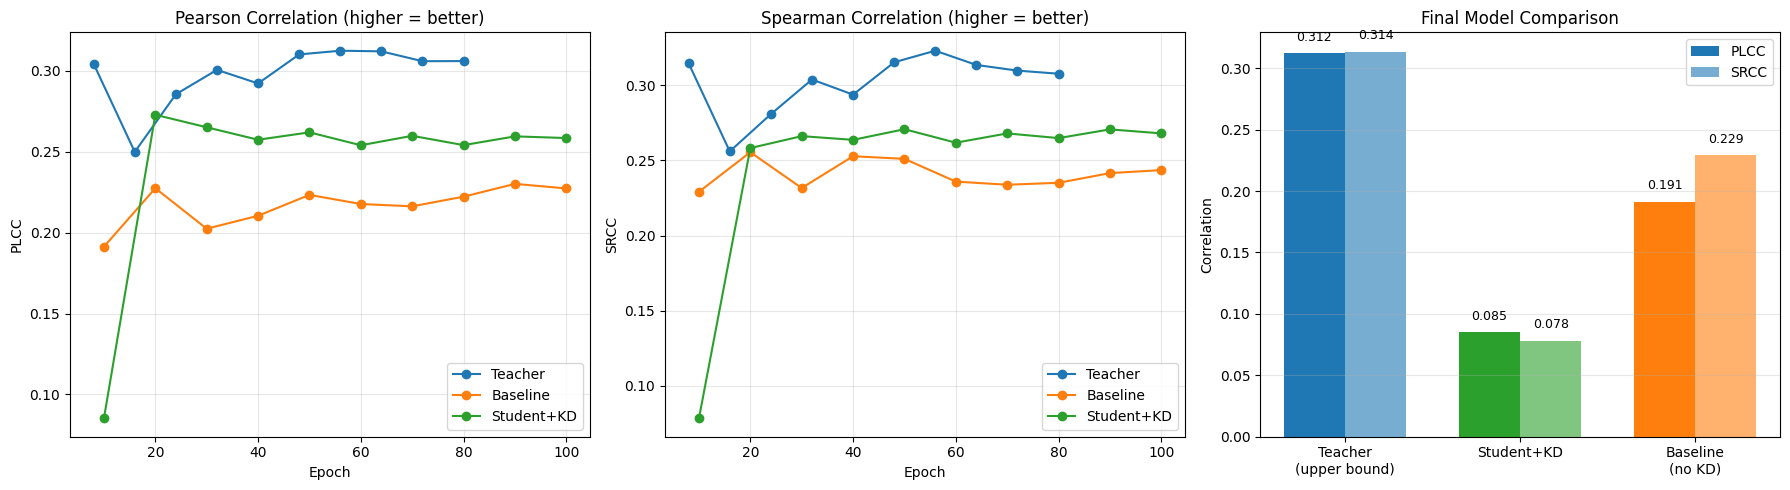

Saved: /kaggle/working/kd_comparison.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PLCC over epochs
for hist, label, color in [(history_teacher, 'Teacher', 'tab:blue'),
                            (history_baseline, 'Baseline', 'tab:orange'),
                            (history_kd, 'Student+KD', 'tab:green')]:
    epochs = [h['epoch'] for h in hist]
    plccs = [h['plcc'] for h in hist]
    axes[0].plot(epochs, plccs, 'o-', label=label, color=color)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('PLCC')
axes[0].set_title('Pearson Correlation (higher = better)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# SRCC over epochs
for hist, label, color in [(history_teacher, 'Teacher', 'tab:blue'),
                            (history_baseline, 'Baseline', 'tab:orange'),
                            (history_kd, 'Student+KD', 'tab:green')]:
    epochs = [h['epoch'] for h in hist]
    srccs = [h['srcc'] for h in hist]
    axes[1].plot(epochs, srccs, 'o-', label=label, color=color)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('SRCC')
axes[1].set_title('Spearman Correlation (higher = better)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Bar chart comparison
models = ['Teacher\n(upper bound)', 'Student+KD', 'Baseline\n(no KD)']
plcc_vals = [teacher_val['plcc'], kd_val['plcc'], baseline_val['plcc']]
srcc_vals = [teacher_val['srcc'], kd_val['srcc'], baseline_val['srcc']]
x = np.arange(len(models))
w = 0.35
axes[2].bar(x - w/2, plcc_vals, w, label='PLCC', color=['tab:blue', 'tab:green', 'tab:orange'])
axes[2].bar(x + w/2, srcc_vals, w, label='SRCC', color=['tab:blue', 'tab:green', 'tab:orange'], alpha=0.6)
axes[2].set_xticks(x); axes[2].set_xticklabels(models)
axes[2].set_ylabel('Correlation'); axes[2].set_title('Final Model Comparison')
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')
for i, (p, s) in enumerate(zip(plcc_vals, srcc_vals)):
    axes[2].text(i - w/2, p + 0.01, f'{p:.3f}', ha='center', fontsize=9)
    axes[2].text(i + w/2, s + 0.01, f'{s:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kd_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR}/kd_comparison.png")